<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 1.1 MB
<class 'pandas.DataFrame'>
Index: 8886 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          -------------

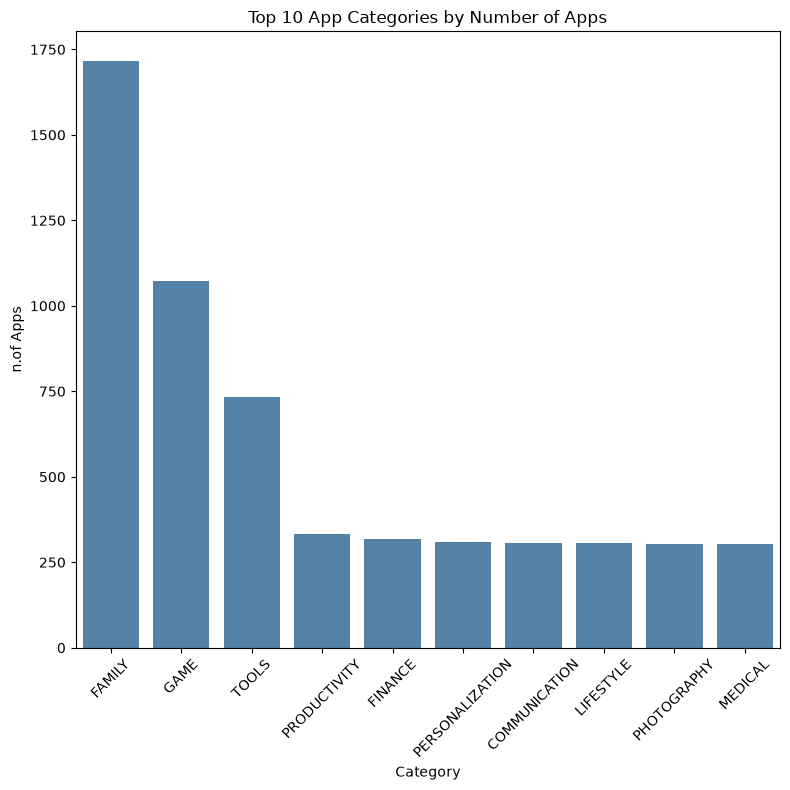

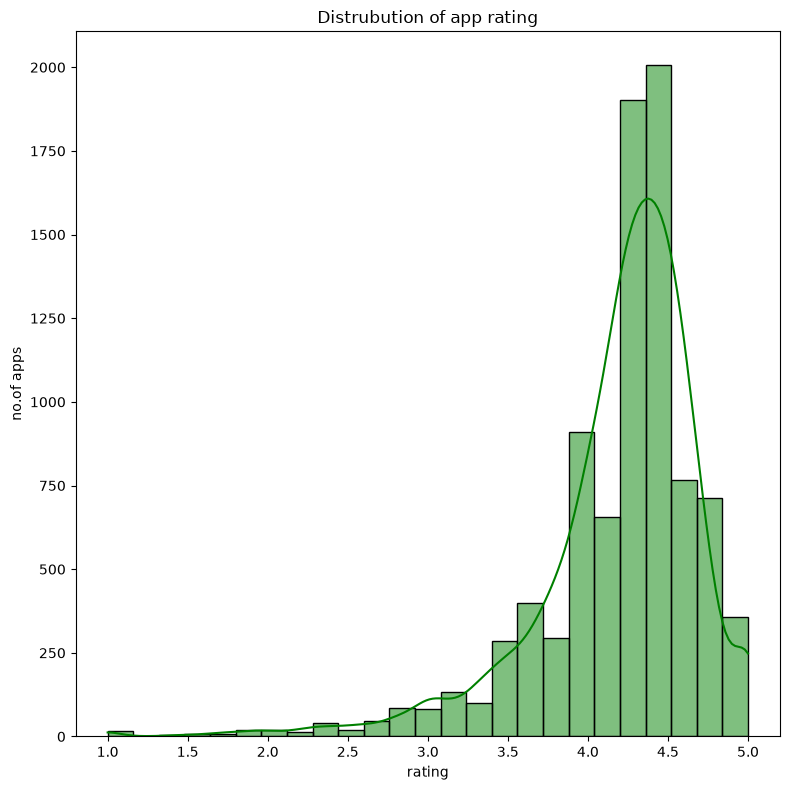

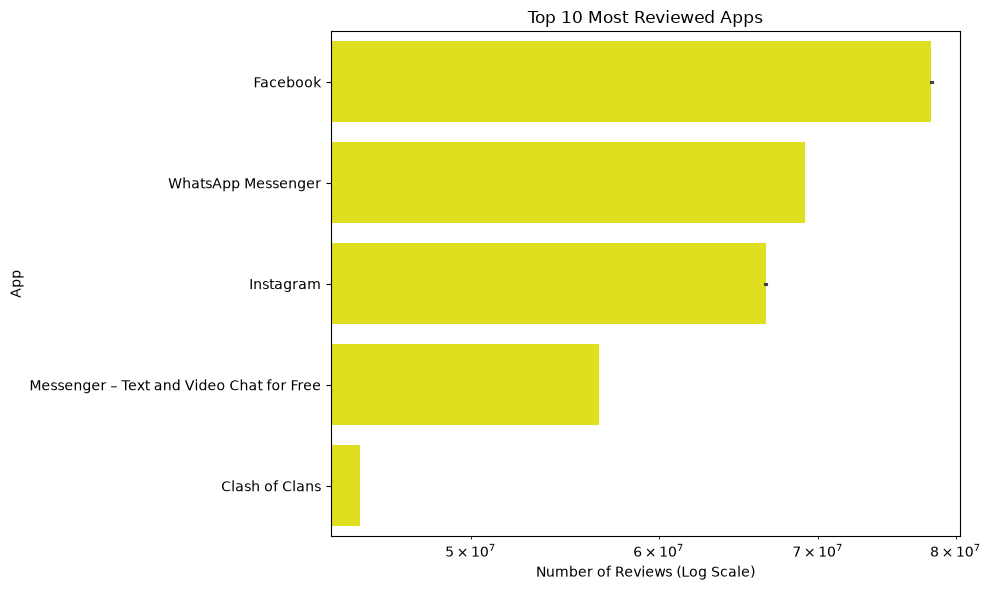

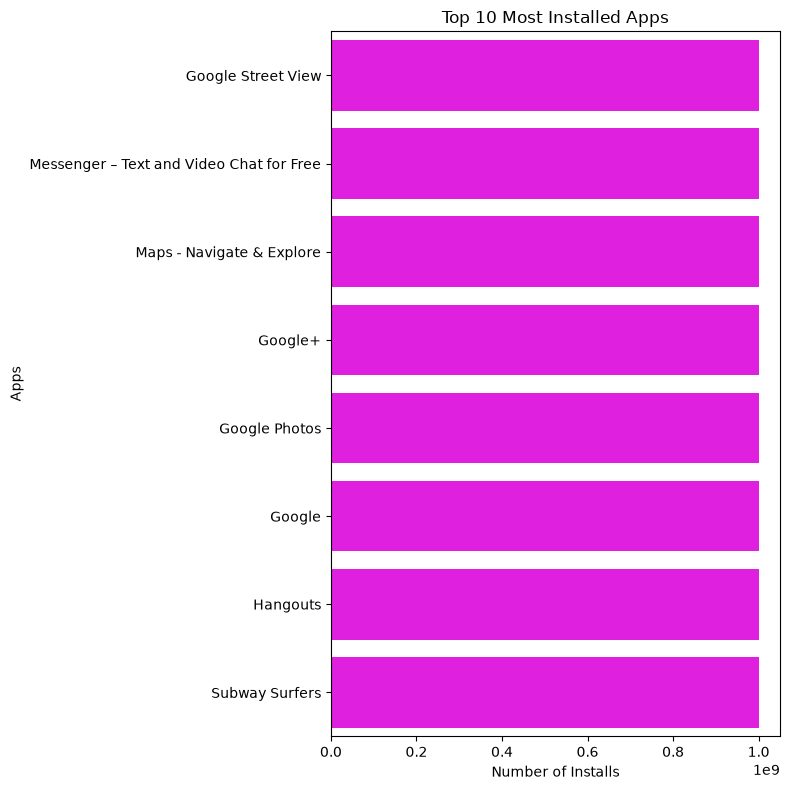

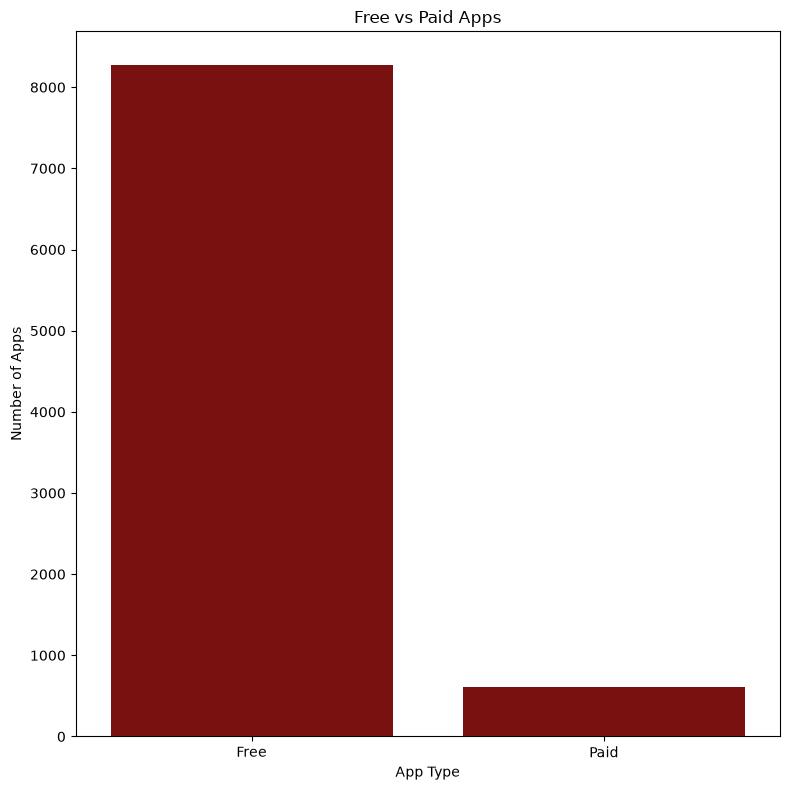

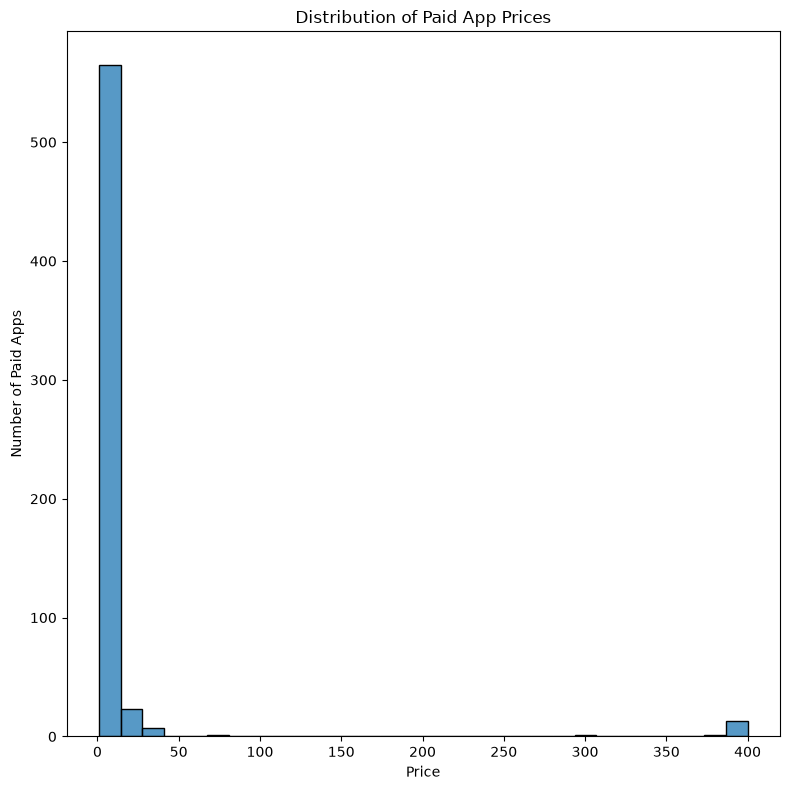

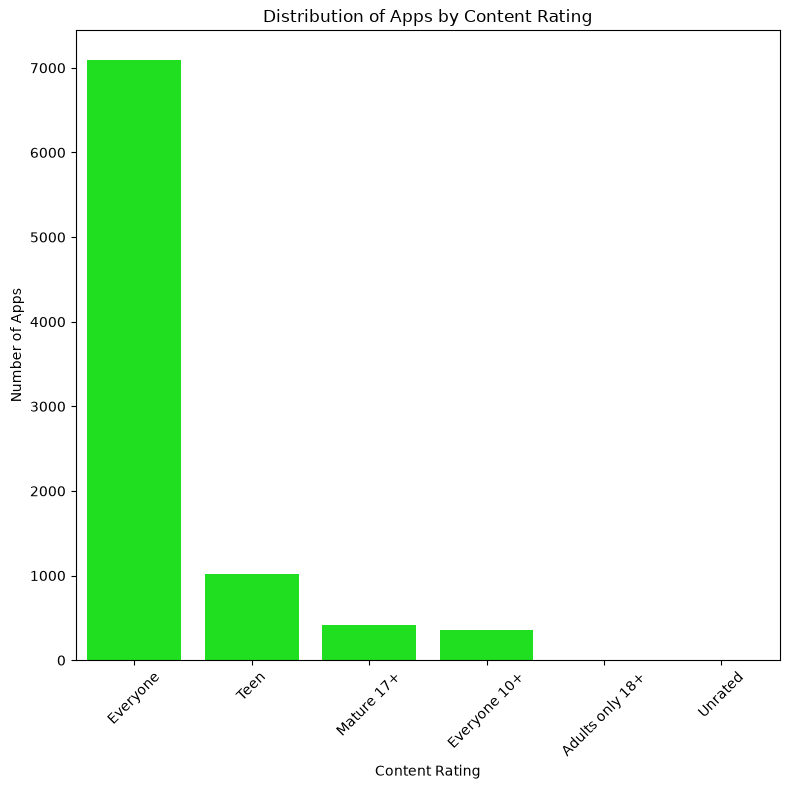

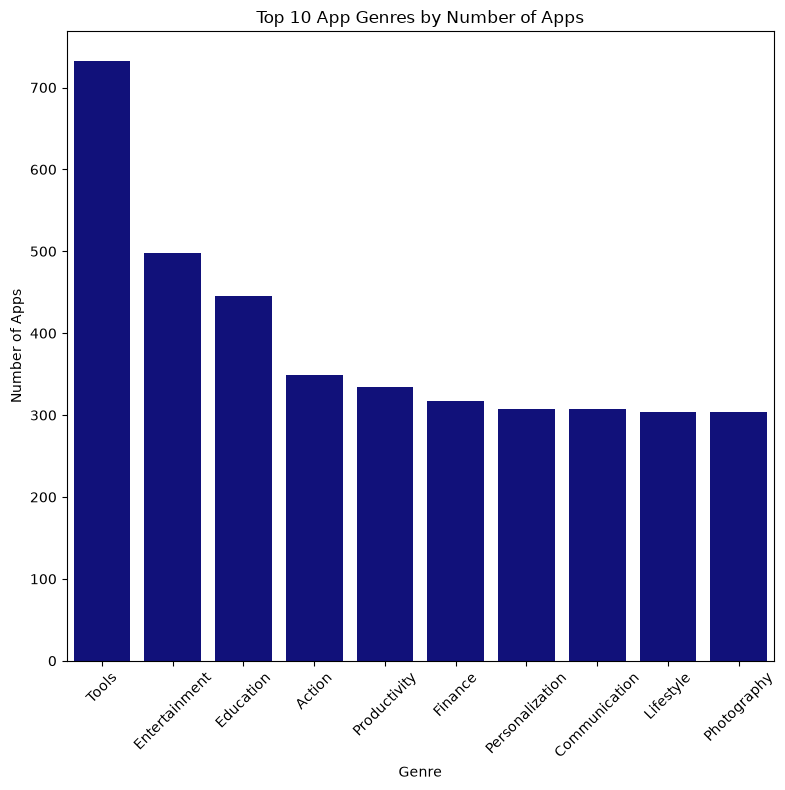

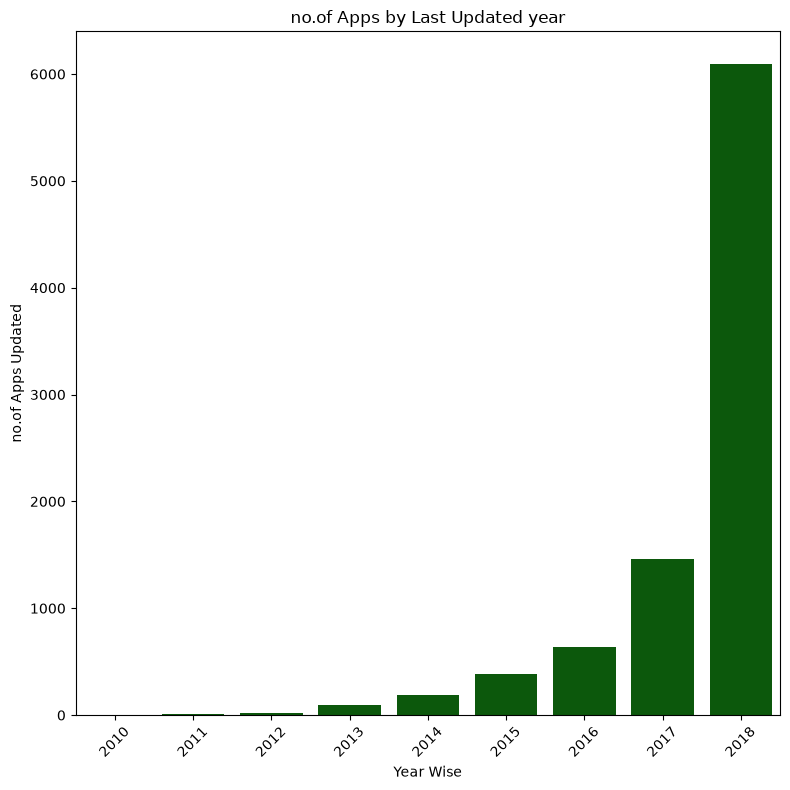

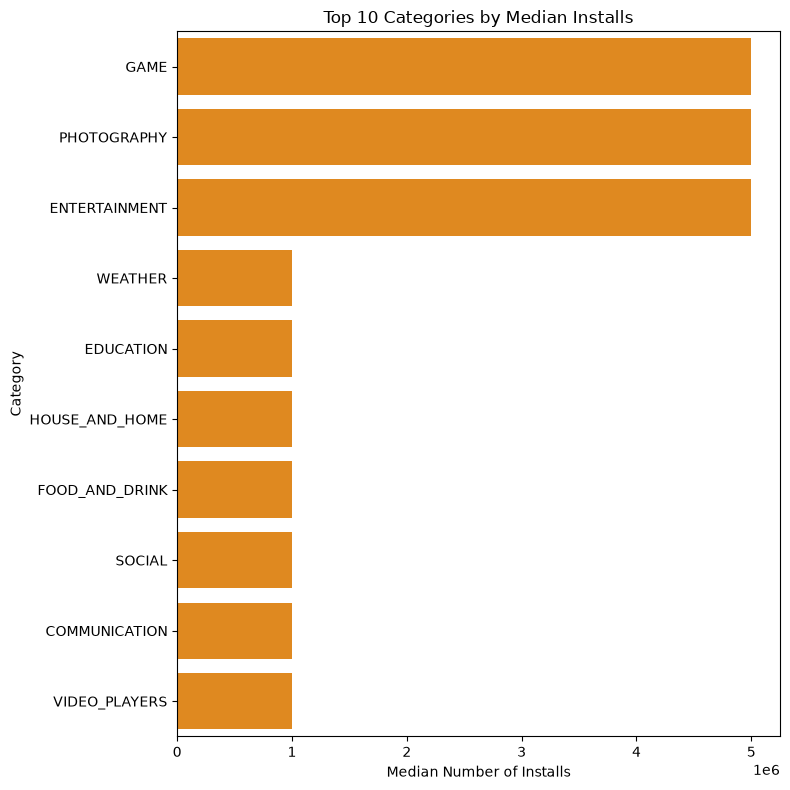

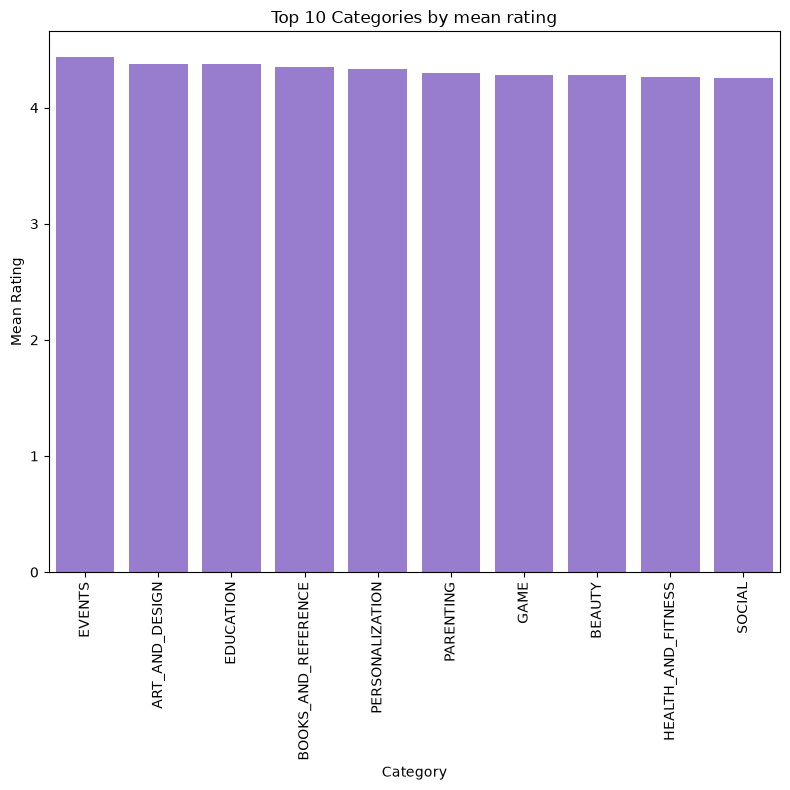

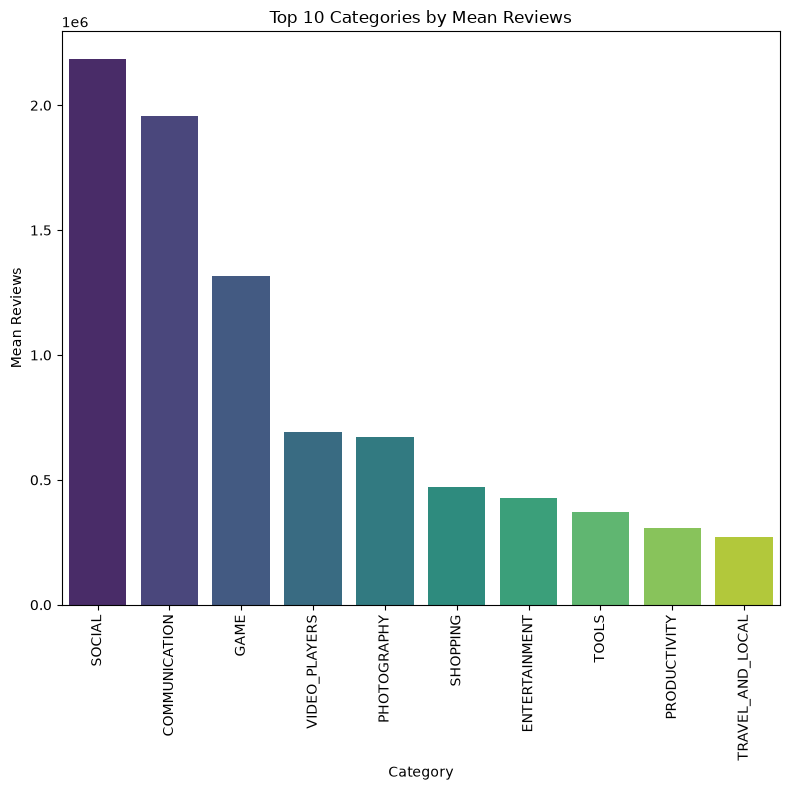

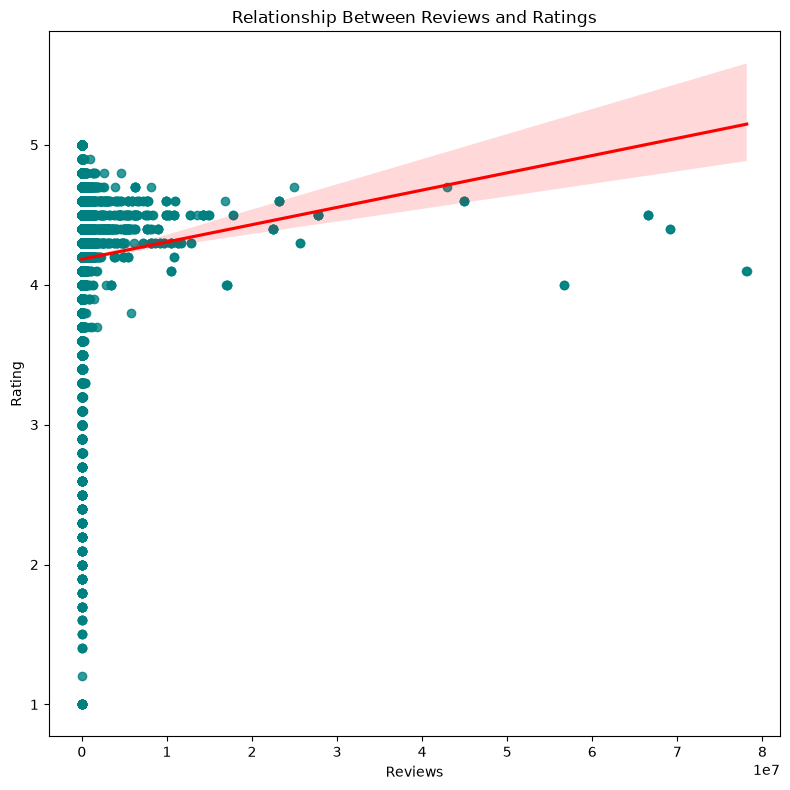

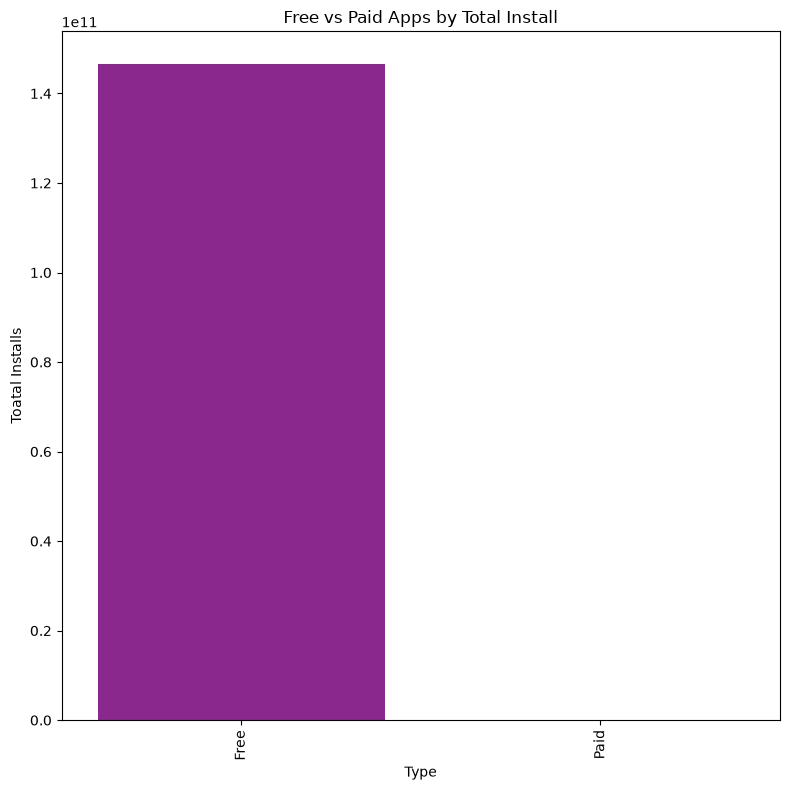

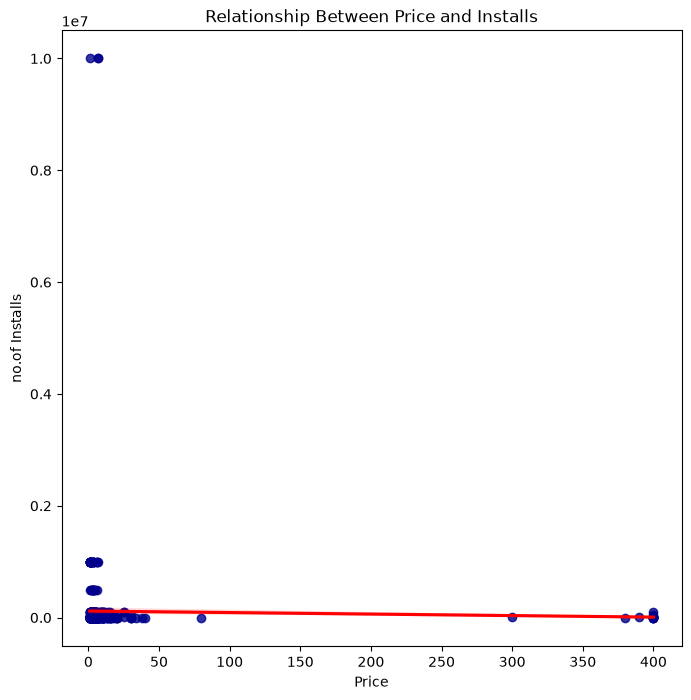

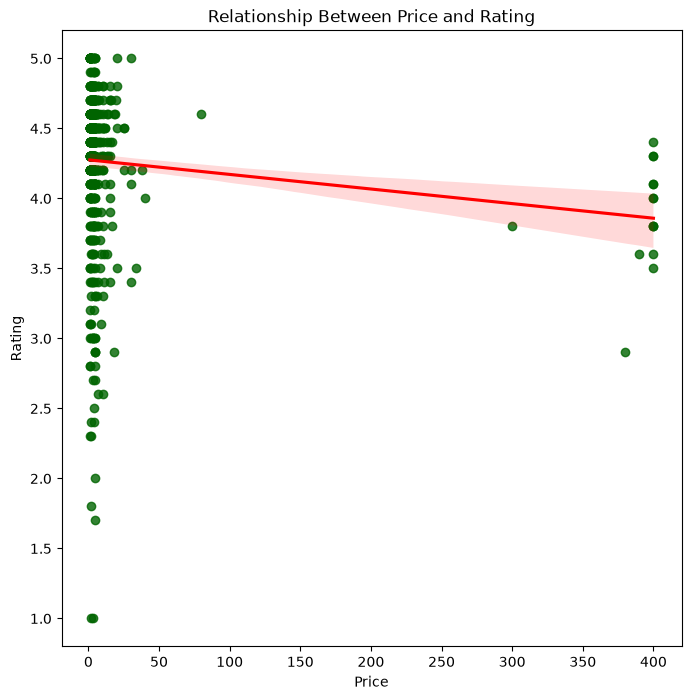

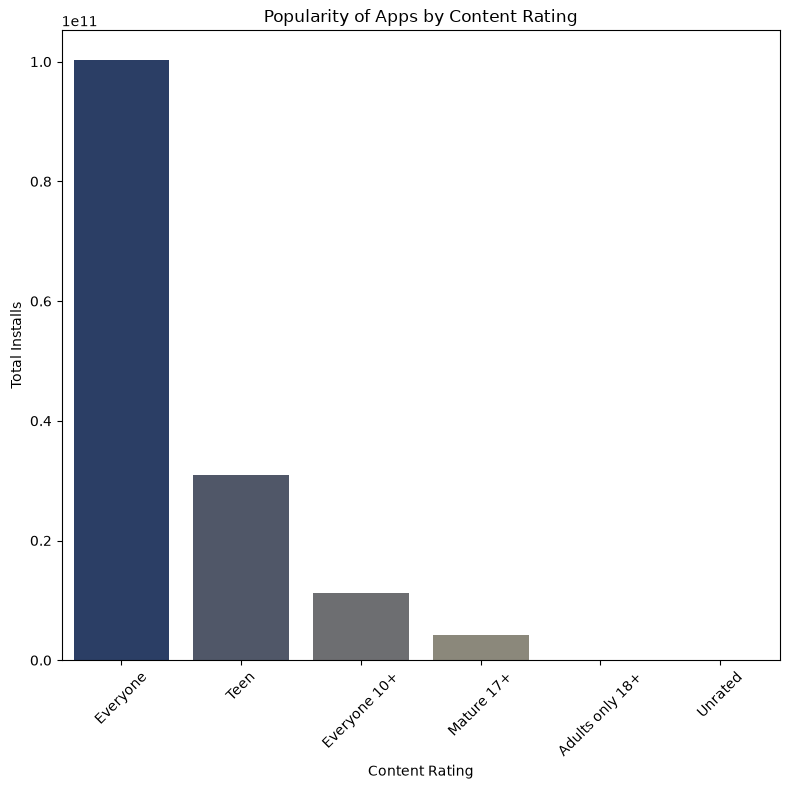

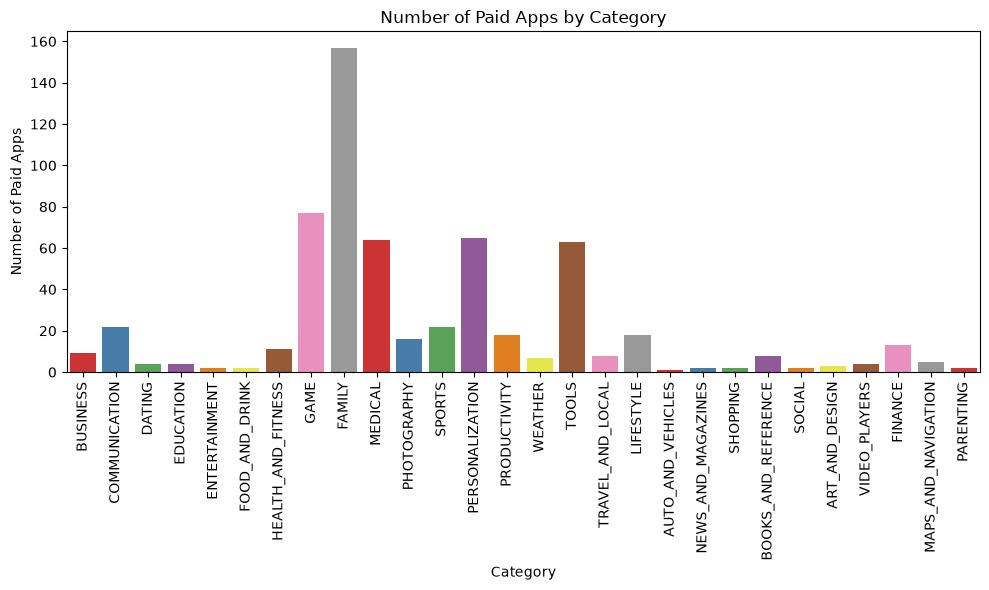

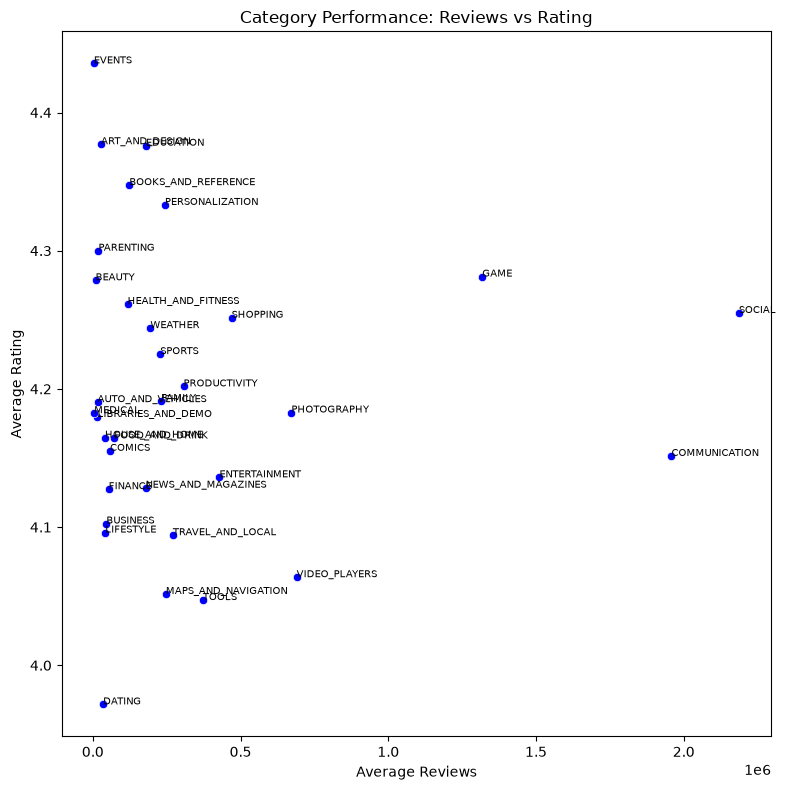

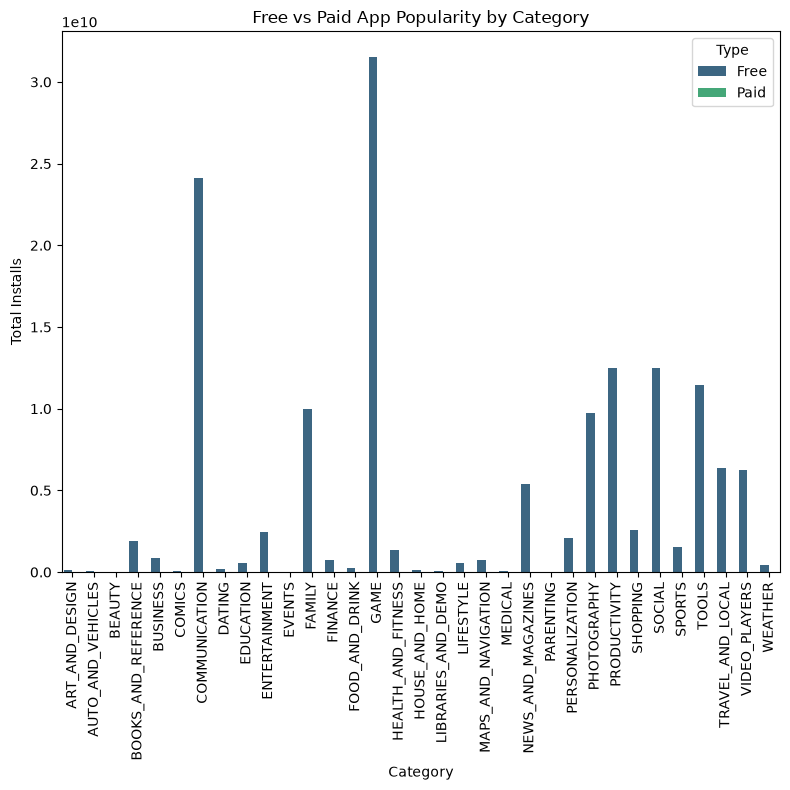

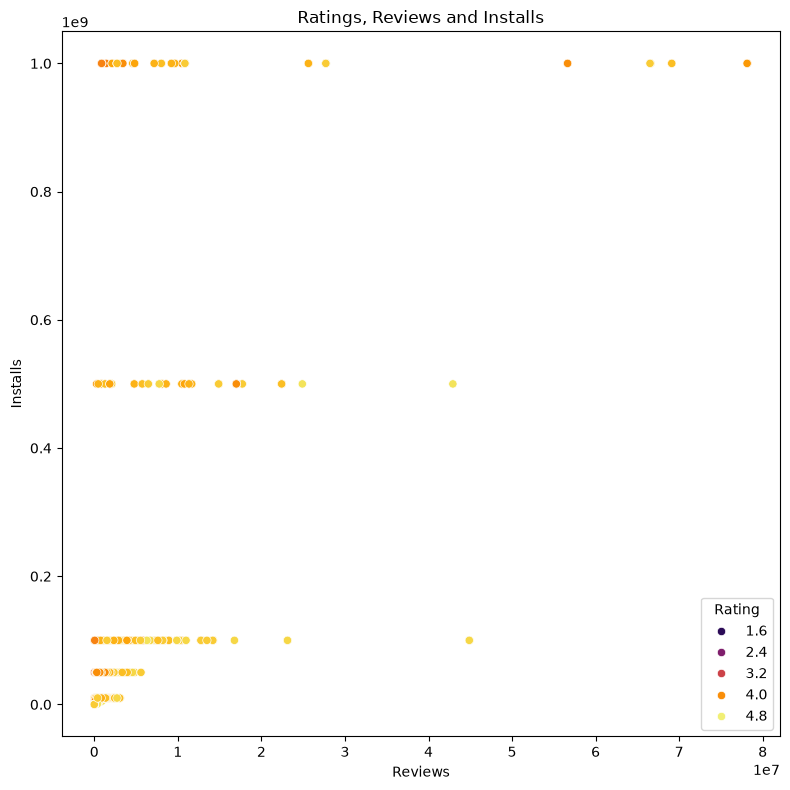

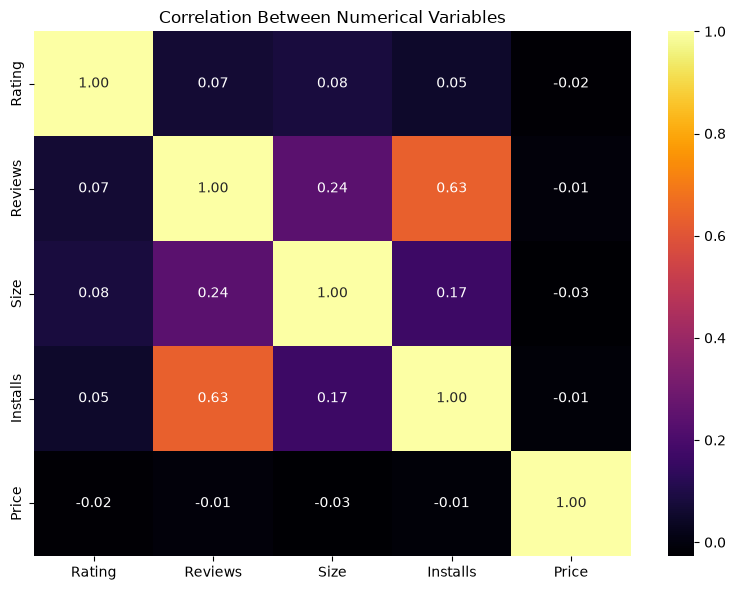

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import warnings
warnings.filterwarnings(action='ignore')
df=pd.read_csv('Google_Play_Store_Raw_Data.csv')
df.head(1)
df.info()
df.describe()
df.shape
#duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)
#null vaues
df.isnull().sum()
df.dropna(inplace=True)
df.isnull().sum()
df.shape
df.dtypes
#print(df.columns)
#print(df.head())
#print(df.nunique())
#print(df.dtypes)

## here we want to change the datatypes of columns to correct ones
#reviews column is in str format we want to change it to int format
df['Reviews']=pd.to_numeric(df['Reviews'],errors='coerce')
df['Reviews'].dtypes
#Installs column is in str format we want to change it to int format
df['Installs']=df['Installs'].str.replace(',','').str.replace('+','')
df['Installs']=pd.to_numeric(df['Installs'],errors='coerce')
df['Installs'].dtypes
df.dtypes
# Price
df['Price'].dtypes
df['Price']=df['Price'].str.replace('$','',regex=False)
df['Price']=pd.to_numeric(df['Price'])
df.dtypes
#Size column in the str format but it not like that
df['Size'].value_counts().head(10)
# df['Size']=pd.to_numeric(df['Size']) we perform this here we get the error at 0 poisition
df['Size']=df['Size'].str.replace('M','',regex=False)
df['Size'].head()
#df['Size']=pd.to_numeric(df['Size'])
#for the Count of K>Kb presesnt in the Size Column
df['Size'].str.contains('k', case=False, na=False).sum()

# to see the k cointain rows in Size columns
df[df['Size'].str.contains('k',case=False,na=False)]['Size'].head(10)
# to change the k > mb 
#df['Size']=df['Size'].str.replace('k','',regex=False)
#df['Size'].head(15)
#df['Size']=df['Size'].str.strip('k')
#df[df['Size'].str.contains('k',case=False,na=False)]['Size'].head(10)
def convert_size(x):
    if 'k' in x:
        return float(x.replace('k', '')) / 1024
    return x

df['Size'] = df['Size'].apply(convert_size)
#df[df['Size'].str.contains('k',case=False,na=False)]['Size'].head(10)
df['Size'].value_counts().head(10)
#also here present the 'varies with device' in the size column so we need to Count total how many are present in it
df[df['Size'] == 'Varies with device'].shape
#we shold not perform the dropna here beacouse we loose the 1468 apps data so use replace fun
df['Size']=df['Size'].replace('Varies with device',np.nan)
df['Size']=pd.to_numeric(df['Size'])
df.dtypes
#we want change the datatype of column Last Updated to Datetime
df['Last Updated']=pd.to_datetime(df['Last Updated'])
df.dtypes
# 
df['Current Ver'].value_counts().head(10)
df['Android Ver'].value_counts().head(10)
df.isnull().sum()
df.duplicated().sum()
df.shape
df.info()
df.describe()
df.duplicated().sum()

print('---------------------')
print(df.shape)
print('---------------------')
print(df.columns)
print('---------------------')
print(df.dtypes)
print('---------------------')
print(df.info())
print('---------------------')
print(df.head(5))
print('---------------------')

df.to_csv('Google_Play_Store_Cleaned.csv', index=False)

##Univariate obsevations
#1.Which app categories have the highest number of apps in the Google Play Store?
category_count=df['Category'].value_counts().head(10)
plt.figure(figsize=(8,8))
sb.barplot(x=category_count.index,y=category_count.values,color='steelblue')
plt.title("Top 10 App Categories by Number of Apps")
plt.xlabel('Category')
plt.ylabel('n.of Apps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Top 10 App Categories by Number of Apps.png',dpi=150)
plt.show()

#2.Which app categories have the most apps on the Google Play Store by rating?
#rating wise apps install count and distribution observation
plt.figure(figsize=(8,8))
sb.histplot(df['Rating'],bins=25,kde=True,color='green')
plt.title('Distrubution of app rating')
plt.xlabel('rating')
plt.ylabel('no.of apps')
plt.tight_layout()
plt.savefig('Distrubution of app rating.png',dpi=150)
plt.show()

#3.Which apps get the most reviews from users?
top_reviewed=df.nlargest(10,'Reviews')
plt.figure(figsize=(10, 6))
sb.barplot(data=top_reviewed,x='Reviews',y='App',color='yellow')
plt.xscale('log')
plt.title('Top 10 Most Reviewed Apps')
plt.xlabel('Number of Reviews (Log Scale)')
plt.ylabel('App')
plt.tight_layout()
plt.savefig('Top 10 Most Reviewed Apps.png',dpi=150)
plt.show()

#4.Which App is most popular among the users(by Installs) 
top_installed=df.sort_values(by='Installs',ascending=False).head(10)
plt.figure(figsize=(8,8))
sb.barplot(data=top_installed,x='Installs',y='App',color='magenta')
#plt.xscale('log')
plt.title('Top 10 Most Installed Apps')
plt.xlabel('Number of Installs')
plt.ylabel('Apps')
plt.tight_layout()
plt.savefig('Top 10 Most Installed Apps.png',dpi=150)
plt.show()

#5.Most apps on the Google Play Store free or paid?
type_count = df['Type'].value_counts()
plt.figure(figsize=(8, 8))
sb.barplot(x=type_count.index,y=type_count.values,color='darkred')
plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.savefig('Free vs Paid Apps.png',dpi=150)
plt.show()

#6.How much do paid apps usually cost? (by using Type and Price)
df.columns
paid_apps=df[df['Type']=='Paid']
plt.figure(figsize=(8,8))
sb.histplot(data=paid_apps,x='Price',bins=30)
plt.title('Distribution of Paid App Prices')
plt.xlabel('Price')
plt.ylabel('Number of Paid Apps')
plt.tight_layout()
plt.savefig('Distribution of Paid App Prices.png',dpi=150)
plt.show()

#7.Which age audience do most apps target?
df.columns
plt.figure(figsize=(8,8))
content_rating_count=df['Content Rating'].value_counts()
sb.barplot(x=content_rating_count.index,y=content_rating_count.values,color='lime')
plt.title('Distribution of Apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Distribution of Apps by Content Rating.png',dpi=150)
plt.show()

#8.Which genres have most apps on the Google Play Store?
df.columns
genres_count=df['Genres'].value_counts().head(10)
plt.figure(figsize=(8,8))
sb.barplot(x=genres_count.index,y=genres_count.values,color='DarkBlue')
plt.title('Top 10 App Genres by Number of Apps')
plt.xlabel('Genre')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Top 10 App Genres by Number of Apps.png',dpi=150)
plt.show()

#9.When Play Store most apps last updated?
df.columns
df['Updated Year']=df['Last Updated'].dt.year
updated_year=df['Updated Year'].value_counts().sort_index()
plt.figure(figsize=(8,8))
sb.barplot(x=updated_year.index,y=updated_year.values,color='darkgreen')
plt.title('no.of Apps by Last Updated year')
plt.xlabel('Year Wise')
plt.ylabel('no.of Apps Updated')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('no.of Apps by Last Updated year.png',dpi=150)
plt.show()
###
##1.Which categories are most popular?
#here we use the both(Category&Installs)
df.columns
category_installs_median=df.groupby('Category')['Installs'].median()
category_installs=category_installs_median.sort_values(ascending=False).head(10)
plt.figure(figsize=(8,8))
#here we take HoriZonatal Bar for Better Understand purpose
sb.barplot(x=category_installs.values,y=category_installs.index,color='darkorange')
plt.title('Top 10 Categories by Median Installs')
plt.xlabel('Median Number of Installs')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('Top 10 Categories by Median Installs.png',dpi=150)
plt.show()

##2.Which categories get better ratings?
#by using the the columns(Category&Rating)
df[['Category','Rating']].head(10)
category_rating_mean=df.groupby('Category')['Rating'].mean()
category_rating=category_rating_mean.sort_values(ascending=False).head(10)
plt.figure(figsize=(8,8))
sb.barplot(x=category_rating.index,y=category_rating.values,color='mediumpurple')
plt.title('Top 10 Categories by mean rating')
plt.xlabel('Category')
plt.ylabel('Mean Rating')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Top 10 Categories by Mean Rrating.png',dpi=150)
plt.show()

##3.Which categories get more reviews?
#by using the columns(Category&Reviews)
df[['Category','Reviews']].head(10)
category_reviews_mean=df.groupby('Category')['Reviews'].mean()
category_reviews=category_reviews_mean.sort_values(ascending=False).head(10)
plt.figure(figsize=(8,8))
sb.barplot(x=category_reviews.index,y=category_reviews.values,palette='viridis')
plt.title('Top 10 Categories by Mean Reviews')
plt.xlabel('Category')
plt.ylabel('Mean Reviews')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Top 10 Categories by Mean Reviews.png',dpi=150)
plt.show()

##4.Do apps with more reviews get higher ratings?
#by using the columns(Reviews&Rating)
#here we use scatterplot or regplot,etc,... Because of two columns are numerical.
df[['Reviews','Rating']].head(10)
plt.figure(figsize=(8,8))
sb.regplot(x='Reviews',y='Rating',data=df,scatter_kws={'color':'teal'},line_kws={'color':'red'})
plt.title('Relationship Between Reviews and Ratings')
plt.xlabel('Reviews')
plt.ylabel('Rating')
plt.tight_layout()
plt.savefig('Relationship Between Reviews and Ratings.png',dpi=150)
plt.show()

##5.In Play Store free apps more popular than paid apps?
#by using the columns(Type&Installs)
df[['Type','Installs']].head(10)
type_installs=df.groupby('Type')['Installs'].sum()
plt.figure(figsize=(8,8))
sb.barplot(x=type_installs.index,y=type_installs.values,palette='plasma')
plt.title('Free vs Paid Apps by Total Install')
plt.xlabel('Type')
plt.ylabel('Toatal Installs')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Free vs Paid Apps by Total Install.png',dpi=150)
plt.show()

##6.Price affect app popularity Yes Or No?
#by using the columns(Price&Installs)
#both columns are numerical colums so,we use scatterplt or regplot
dff=df[df['Type']=='Paid']
plt.figure(figsize=(8,8))
sb.regplot(data=dff,x='Price',y='Installs',scatter_kws={'color':'darkblue'},line_kws={'color':'red'})
plt.title('Relationship Between Price and Installs')
plt.xlabel('Price')
plt.ylabel('no.of Installs')
plt.savefig('Relationship Between Price and Installs.png',dpi=150)
plt.show()

##7.Expensive apps get better ratings or not?
#by using the columns(Price&Rating)
##both columns are numerical colums so,we use scatterplt or regplot
Paid=df[df['Type']=='Paid']
plt.figure(figsize=(8,8))
sb.regplot(data=Paid,x='Price',y='Rating',scatter_kws={'color':'darkgreen'},line_kws={'color':'red'})
plt.title('Relationship Between Price and Rating')
plt.xlabel('Price')
plt.ylabel('Rating')
plt.savefig('Relationship Between Price and Rating.png',dpi=150)
plt.show()

##8.Which audience apps are more popular?
#by using the columns (Content Rating × Installs)
df[['Content Rating', 'Installs']].head(10)
content_rating_installs = df.groupby('Content Rating')['Installs'].sum()
content_rating_installs = content_rating_installs.sort_values(ascending=False)
plt.figure(figsize=(8, 8))
sb.barplot(x=content_rating_installs.index,y=content_rating_installs.values,palette='cividis')
plt.title('Popularity of Apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Total Installs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Popularity of Apps by Content Rating.png',dpi=150)
plt.show()

##9. Which categories have more paid apps?
#by using the columns (Category × Type)
df[['Category', 'Type']].head(10)
cat_pad=df[df['Type'] == 'Paid']
plt.figure(figsize=(10, 6))
sb.countplot(data=cat_pad,x='Category',palette='Set1')
plt.title('Number of Paid Apps by Category')
plt.xlabel('Category')
plt.ylabel('Number of Paid Apps')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Number of Paid Apps by Category.png',dpi=150)
plt.show()
####
##1.Which categories have good ratings and more reviews?
#by using the columns(Category&Rating&Reviews)
category_performance = df.groupby('Category').agg({'Rating': 'mean','Reviews': 'mean'})
plt.figure(figsize=(8,8))
sb.scatterplot(data=category_performance,x='Reviews',y='Rating',color='blue')
for category, row in category_performance.iterrows():
    plt.text(row['Reviews'],row['Rating'],category,fontsize=7)
plt.title('Category Performance: Reviews vs Rating')
plt.xlabel('Average Reviews')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.savefig('Category Performance by Reviews vs Rating.png',dpi=150)
plt.show()

##2.Which categories are popular for both free and paid apps?
#by using the columns (Category&Type&Installs)
category_type_installs = df.groupby(['Category', 'Type'])['Installs'].sum().reset_index()
plt.figure(figsize=(8,8))
sb.barplot(data=category_type_installs,x='Category',y='Installs',hue='Type',palette='viridis')
plt.title('Free vs Paid App Popularity by Category')
plt.xlabel('Category')
plt.ylabel('Total Installs')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('Free vs Paid App Popularity by Category.png',dpi=150)
plt.show()

##3.Do highly rated apps get more reviews and installs?
#by using the columns (Rating × Reviews × Installs)
df[['Rating', 'Reviews', 'Installs']].head(10)
plt.figure(figsize=(8,8))
sb.scatterplot(data=df,x='Reviews',y='Installs',hue='Rating',palette='inferno')
plt.title('Ratings, Reviews and Installs')
plt.xlabel('Reviews')
plt.ylabel('Installs')
plt.tight_layout()
plt.savefig('Ratings, Reviews and Installs.png',dpi=150)
plt.show()

##4.Which factors are strongly related to each other?
num_cols=['Rating','Reviews','Size','Installs','Price']
correlation=df[num_cols].corr()
plt.figure(figsize=(8,6))
sb.heatmap(correlation,annot=True,cmap='inferno',fmt='.2f')
plt.title('Correlation Between Numerical Variables')
plt.tight_layout()
plt.savefig('Correlation Between Numerical Variables.png',dpi=150)
plt.show()
